# Adding Dynamic Columns

In [87]:
import pandas as pd

titanic = pd.read_csv('../../data/titanic.csv')
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [88]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pclass     1309 non-null   int64 
 1   survived   1309 non-null   int64 
 2   name       1309 non-null   object
 3   sex        1309 non-null   object
 4   age        1309 non-null   object
 5   sibsp      1309 non-null   int64 
 6   parch      1309 non-null   int64 
 7   ticket     1309 non-null   object
 8   fare       1309 non-null   object
 9   cabin      1309 non-null   object
 10  embarked   1309 non-null   object
 11  boat       1309 non-null   object
 12  body       1309 non-null   object
 13  home.dest  1309 non-null   object
dtypes: int64(4), object(10)
memory usage: 143.3+ KB


##### Adding a total_relatives calculated column

In [89]:
total_relatives = (titanic['parch'] + titanic['sibsp'])
titanic.insert(7, '# of Relatives', total_relatives)
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,# of Relatives,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,3,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,3,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,3,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,3,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [90]:
total_relatives = (titanic['parch'] + titanic['sibsp'])
total_relatives

0       0
1       3
2       3
3       3
4       3
       ..
1304    1
1305    1
1306    0
1307    0
1308    0
Length: 1309, dtype: int64

In [91]:
titanic.sort_values('# of Relatives', ascending=False).head()

,pclass,survived,name,sex,age,sibsp,parch,# of Relatives,ticket,fare,cabin,embarked,boat,body,home.dest
1177,3,0,"Sage, Mr. Frederick",male,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1179,3,0,"Sage, Mr. John George",male,?,1,9,10,CA. 2343,69.55,?,S,?,?,?
1173,3,0,"Sage, Miss. Constance Gladys",female,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1170,3,0,"Sage, Master. Thomas Henry",male,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1172,3,0,"Sage, Miss. Ada",female,?,8,2,10,CA. 2343,69.55,?,S,?,?,?


## Find the per square foot price of houses

In [92]:
import pandas as pd

houses = pd.read_csv('../../data/kc_house_data.csv')
houses.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [93]:
houses.insert(3, 'price/sqft', houses['price'] / houses['sqft_living'])
houses.head()

,id,date,price,price/sqft,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,188.050847,3,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,209.338521,3,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,233.766234,2,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,308.163265,4,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,303.571429,3,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [94]:
houses.sort_values(['price/sqft'], ascending=False).head()

,id,date,price,price/sqft,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19336,6021500970,20150407T000000,874950.0,810.138889,2,1.00,1080,4000,1.0,0,...,7,1080,0,1940,0,98117,47.6902,-122.387,1530,4240
4013,724069059,20140509T000000,2400000.0,800.000000,3,2.25,3000,11665,1.5,1,...,11,3000,0,2001,0,98075,47.5884,-122.086,3000,15959
10446,1118000320,20150508T000000,3400000.0,798.122066,4,4.00,4260,11765,2.0,0,...,11,3280,980,1939,2010,98112,47.6380,-122.288,4260,10408
8623,6303400395,20150130T000000,325000.0,792.682927,1,0.75,410,8636,1.0,0,...,4,410,0,1953,0,98146,47.5077,-122.357,1190,8636
9314,4389200610,20141201T000000,903000.0,792.105263,2,1.50,1140,7800,1.0,0,...,6,1140,0,1947,0,98004,47.6142,-122.209,2020,7800


<Axes: xlabel='zipcode'>

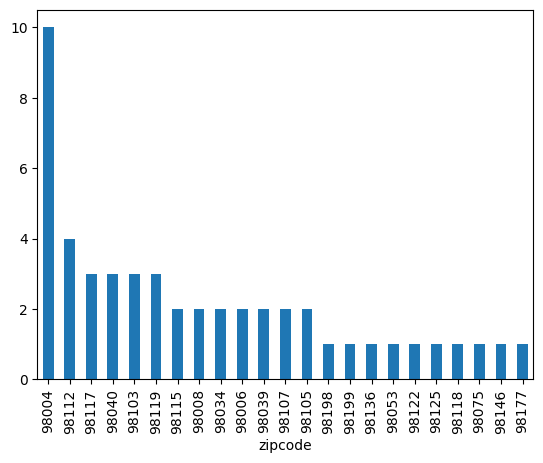

In [95]:
houses.sort_values(['price/sqft'], ascending=False).head(50)['zipcode'].value_counts().plot(kind='bar')

## Finding largest Bitcoin Price Changes

In [96]:
import pandas as pd

btc = pd.read_csv('../../data/coin_Bitcoin.csv')
btc.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


##### Set the Index column to the Date column

In [97]:
btc.set_index('Date', inplace=True)

In [98]:
btc.insert(7, 'Change', btc['Close'] - btc['Open'])

In [99]:
btc.head()

,SNo,Name,Symbol,High,Low,Open,Close,Change,Volume,Marketcap
Date,,,,,,,,,,
2013-04-29 23:59:59,1,Bitcoin,BTC,147.488007,134.000000,134.444000,144.539993,10.095993,0.0,1.603769e+09
2013-04-30 23:59:59,2,Bitcoin,BTC,146.929993,134.050003,144.000000,139.000000,-5.000000,0.0,1.542813e+09
2013-05-01 23:59:59,3,Bitcoin,BTC,139.889999,107.720001,139.000000,116.989998,-22.010002,0.0,1.298955e+09
2013-05-02 23:59:59,4,Bitcoin,BTC,125.599998,92.281898,116.379997,105.209999,-11.169998,0.0,1.168517e+09
2013-05-03 23:59:59,5,Bitcoin,BTC,108.127998,79.099998,106.250000,97.750000,-8.500000,0.0,1.085995e+09


In [100]:
btc.sort_values('Change', ascending=False).head()

,SNo,Name,Symbol,High,Low,Open,Close,Change,Volume,Marketcap
Date,,,,,,,,,,
2021-02-08 23:59:59,2843,Bitcoin,BTC,46203.931437,38076.322807,38886.827290,46196.463719,7309.636429,1.014672e+11,8.603427e+11
2021-04-26 23:59:59,2920,Bitcoin,BTC,54288.002155,48852.796843,49077.792363,54021.754787,4943.962424,5.828404e+10,1.009780e+12
2021-03-01 23:59:59,2864,Bitcoin,BTC,49784.015290,45115.093115,45159.503053,49631.241371,4471.738318,5.389130e+10,9.252355e+11
2021-02-19 23:59:59,2854,Bitcoin,BTC,56113.650547,50937.275722,51675.981285,55888.133682,4212.152397,6.349550e+10,1.041381e+12
2021-04-30 23:59:59,2924,Bitcoin,BTC,57900.719988,53129.600877,53568.663584,57750.177346,4181.513762,5.239593e+10,1.079670e+12


In [102]:
btc.insert(5, 'Delta', btc['High'] - btc['Low'])

In [103]:
btc.head()

,SNo,Name,Symbol,High,Low,Delta,Open,Close,Change,Volume,Marketcap
Date,,,,,,,,,,,
2013-04-29 23:59:59,1,Bitcoin,BTC,147.488007,134.000000,13.488007,134.444000,144.539993,10.095993,0.0,1.603769e+09
2013-04-30 23:59:59,2,Bitcoin,BTC,146.929993,134.050003,12.879990,144.000000,139.000000,-5.000000,0.0,1.542813e+09
2013-05-01 23:59:59,3,Bitcoin,BTC,139.889999,107.720001,32.169998,139.000000,116.989998,-22.010002,0.0,1.298955e+09
2013-05-02 23:59:59,4,Bitcoin,BTC,125.599998,92.281898,33.318100,116.379997,105.209999,-11.169998,0.0,1.168517e+09
2013-05-03 23:59:59,5,Bitcoin,BTC,108.127998,79.099998,29.028000,106.250000,97.750000,-8.500000,0.0,1.085995e+09


In [105]:
btc.sort_values('Delta', ascending=False)

,SNo,Name,Symbol,High,Low,Delta,Open,Close,Change,Volume,Marketcap
Date,,,,,,,,,,,
2021-05-19 23:59:59,2943,Bitcoin,BTC,43546.116485,30681.496912,12864.619573,42944.975447,37002.440466,-5942.534981,1.263581e+11,6.924526e+11
2021-02-23 23:59:59,2858,Bitcoin,BTC,54204.929756,45290.590268,8914.339488,54204.929756,48824.426869,-5380.502887,1.061025e+11,9.099259e+11
2021-05-12 23:59:59,2936,Bitcoin,BTC,57939.362415,49150.533875,8788.828540,56714.533167,49150.533875,-7563.999292,7.521540e+10,9.195278e+11
2021-02-22 23:59:59,2857,Bitcoin,BTC,57533.389325,48967.565188,8565.824137,57532.738864,54207.319065,-3325.419799,9.205242e+10,1.010205e+12
2021-05-21 23:59:59,2945,Bitcoin,BTC,42172.173616,33616.453884,8555.719732,40596.948323,37304.690671,-3292.257651,8.205162e+10,6.981088e+11
...,...,...,...,...,...,...,...,...,...,...,...
2015-09-17 23:59:59,872,Bitcoin,BTC,230.285004,228.925995,1.359009,229.076004,229.809998,0.733994,1.893540e+07,3.360247e+09
2015-06-06 23:59:59,769,Bitcoin,BTC,225.718994,224.378998,1.339996,225.005005,225.619003,0.613998,1.113150e+07,3.213723e+09
2015-05-28 23:59:59,760,Bitcoin,BTC,237.824005,236.651993,1.172012,237.257004,237.408005,0.151001,1.382960e+07,3.373817e+09


<Axes: xlabel='Date'>

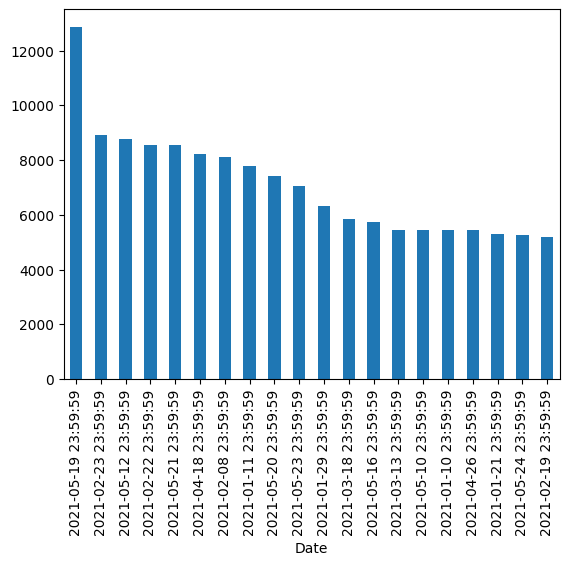

In [111]:
btc.sort_values('Delta', ascending=False)['Delta'].head(20).plot(kind='bar')

<Axes: xlabel='Date'>

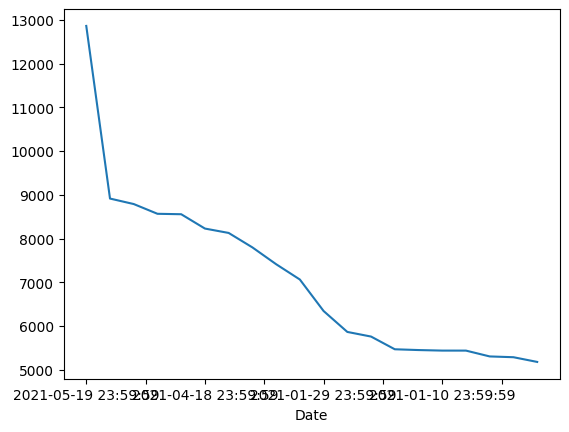

In [112]:
btc.sort_values('Delta', ascending=False)['Delta'].head(20).plot()